In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

import openml
import sys
sys.path.append('..')

from src.data_prep import ColumnSelector

- Im więcej danych usuniemy tym wyniki powinny być zauważalnie gorsze
- Co najmniej jeden dataset z p >> n

In [9]:
from sklearn.discriminant_analysis import StandardScaler


def plot_acc_f1_across_subsets(X, y, n_seeds:int = 3, title: str=''):
    results = {
        "size": [],
        "acc": [],
        "f1": [],
        "bacc": [],
    }

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    sizes = np.arange(0.05, 1.05, 0.1)

    seeds = list(range(n_seeds))

    for size in sizes:
        print(f'Size: {size:.2f}', end=' | ')
        metrics = {"acc": [], "f1": [], "bacc": []}

        for seed in seeds:
            X_train_sub, _, y_train_sub, _ = train_test_split(X_train_full, y_train_full, train_size=size, stratify=y_train_full, random_state=seed)

            if len(np.unique(y_train_sub)) < 2:
                continue

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_sub)
            X_test_scaled = scaler.transform(X_test)

            lr = LogisticRegression(l1_ratio=1, C=1, solver='saga', max_iter=100_000)
            lr.fit(X_train_scaled, y_train_sub.ravel())
            y_hat = lr.predict(X_test_scaled)

            metrics['acc'].append(accuracy_score(y_test, y_hat))
            metrics['f1'].append(f1_score(y_test, y_hat))
            metrics['bacc'].append(balanced_accuracy_score(y_test, y_hat))

        if len(metrics['acc']) > 0:
            avg_acc = np.mean(metrics['acc'])
            avg_f1 = np.mean(metrics['f1'])
            avg_bacc = np.mean(metrics['bacc'])
            
            results['size'].append(size)
            results['acc'].append(avg_acc)
            results['f1'].append(avg_f1)
            results['bacc'].append(avg_bacc)
            
            print(
                f"Acc: {avg_acc:.4f} "
                f"Bacc: {avg_bacc:.4f} "
                f"F1: {avg_f1:.4f} "
                )
        else:
            print("Skipped")

    
    plt.figure(figsize=(10, 6))
    plt.plot(results['size'], results['acc'], marker='o', label='Accuracy')
    plt.plot(results['size'], results['bacc'], marker='^', label='Balanced Accuracy')
    plt.plot(results['size'], results['f1'], marker='s', label='F1-Score')
    
    plt.title(f"{title}")
    plt.xlabel("Proportion of training data")
    plt.ylabel("Metric value (Test data)")
    plt.legend()
    plt.grid(True)
    
    plt.show()

### spam

In [48]:
from ucimlrepo import fetch_ucirepo 

selector = ColumnSelector()
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 

# data (as pandas dataframes) 
spam_X = spambase.data.features .to_numpy()
spam_y = spambase.data.targets.to_numpy()

Size: 0.05 | Acc: 0.8727 Bacc: 0.8633 F1: 0.8339 
Size: 0.15 | Acc: 0.9013 Bacc: 0.8954 F1: 0.8738 
Size: 0.25 | Acc: 0.9115 Bacc: 0.9061 F1: 0.8869 
Size: 0.35 | Acc: 0.9211 Bacc: 0.9165 F1: 0.8994 
Size: 0.45 | Acc: 0.9231 Bacc: 0.9181 F1: 0.9016 
Size: 0.55 | Acc: 0.9225 Bacc: 0.9174 F1: 0.9009 
Size: 0.65 | Acc: 0.9252 Bacc: 0.9202 F1: 0.9043 
Size: 0.75 | Acc: 0.9272 Bacc: 0.9215 F1: 0.9064 
Size: 0.85 | Acc: 0.9270 Bacc: 0.9212 F1: 0.9061 


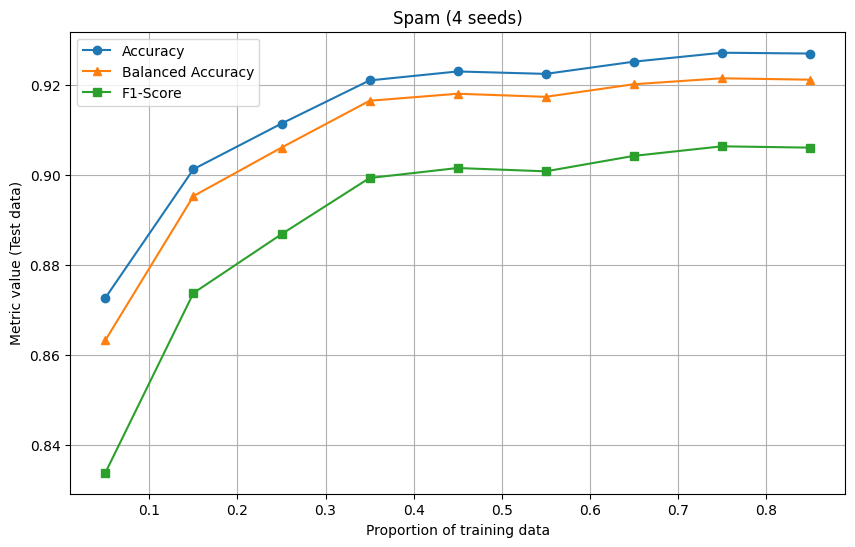

In [78]:
k = 4
plot_acc_f1_across_subsets(spam_X, spam_y, n_seeds=k, title=f'Spam ({k} seeds)')

Not really a big difference (y scale)

### ozone

In [ ]:
dataset = openml.datasets.get_dataset(1487)

ozone_X, ozone_y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe"
)

ozone_y = ozone_y.astype(int)
ozone_y = np.where(np.isin(ozone_y, [1]), 0, 1)

Size: 0.05 | Acc: 0.9320 Bacc: 0.5678 F1: 0.2030 
Size: 0.15 | Acc: 0.9353 Bacc: 0.5890 F1: 0.2588 
Size: 0.25 | Acc: 0.9356 Bacc: 0.5989 F1: 0.2924 
Size: 0.35 | Acc: 0.9396 Bacc: 0.6083 F1: 0.3231 
Size: 0.45 | Acc: 0.9405 Bacc: 0.6331 F1: 0.3741 
Size: 0.55 | Acc: 0.9445 Bacc: 0.6449 F1: 0.4071 
Size: 0.65 | Acc: 0.9438 Bacc: 0.6421 F1: 0.3995 
Size: 0.75 | Acc: 0.9461 Bacc: 0.6482 F1: 0.4175 
Size: 0.85 | Acc: 0.9474 Bacc: 0.6538 F1: 0.4328 


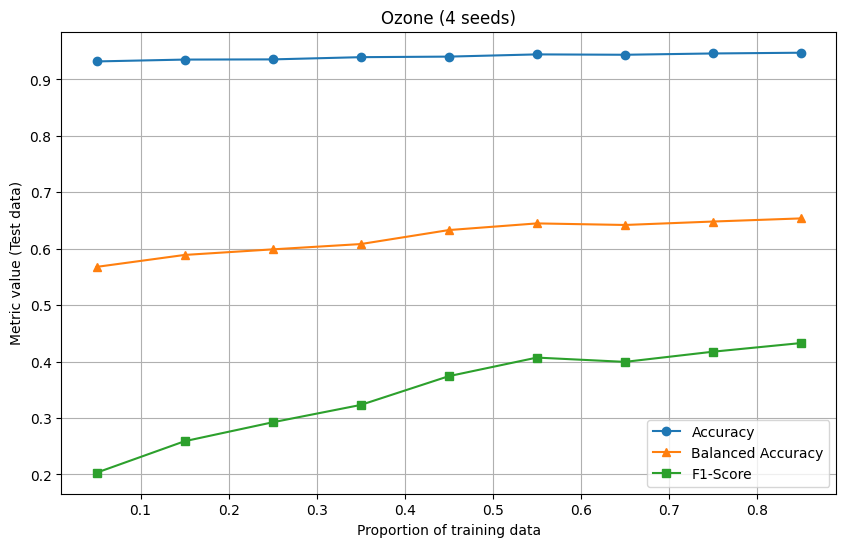

In [143]:
k = 4
plot_acc_f1_across_subsets(ozone_X, ozone_y, n_seeds=k, title=f'Ozone ({k} seeds)')

In terms of F1 a bit better but acc and bacc almost no difference

### prostate

In [ ]:
prostate = pd.read_csv('../data/raw/prostmat.csv', header=None).T

X = prostate.iloc[:, 1:].to_numpy()
y = prostate.iloc[:, 0].to_numpy()
# y = np.where(y == 'cancer', 1, 0)

prostate = pd.read_csv('../data/raw/prostmat.csv', header=None).T

prostate_X = prostate.iloc[:, 1:].to_numpy()
prostate_y = prostate.iloc[:, 0].to_numpy()
prostate_y

array([-0.93089516, -0.83999635,  0.06250801, ...,  0.34722811,
       -0.9013103 , -0.25225949], shape=(6033,))

Size: 0.05 | Acc: 0.5097 Bacc: 0.5021 F1: 0.5274 
Size: 0.15 | Acc: 0.6194 Bacc: 0.6229 F1: 0.5660 
Size: 0.25 | Acc: 0.6065 Bacc: 0.6038 F1: 0.6434 
Size: 0.35 | Acc: 0.6323 Bacc: 0.6329 F1: 0.6314 
Size: 0.45 | Acc: 0.7032 Bacc: 0.7021 F1: 0.7154 
Size: 0.55 | Acc: 0.7613 Bacc: 0.7617 F1: 0.7612 
Size: 0.65 | Acc: 0.7419 Bacc: 0.7408 F1: 0.7448 
Size: 0.75 | Acc: 0.7548 Bacc: 0.7562 F1: 0.7496 
Size: 0.85 | Acc: 0.8323 Bacc: 0.8337 F1: 0.8282 


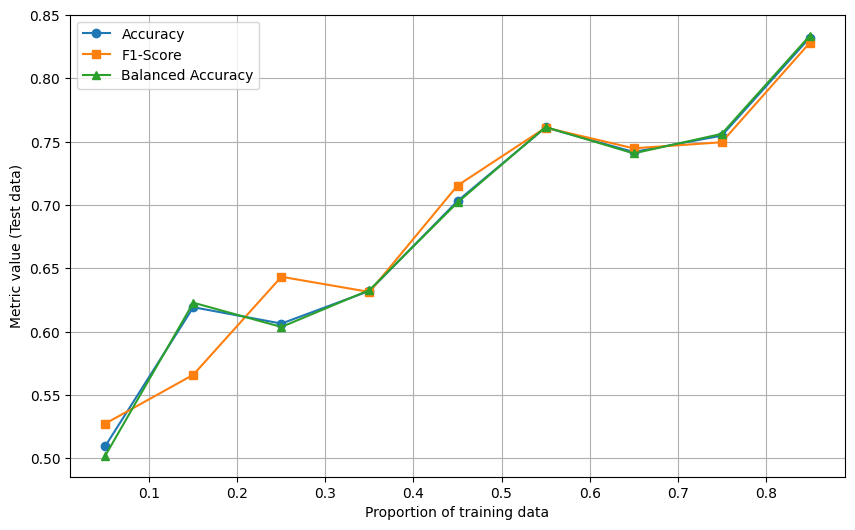

In [54]:
k = 3
plot_acc_f1_across_subsets(X, y, n_seeds=5, title=f'Prostate ({k} seeds')

Ideal (and p >> n)

### darwin

In [ ]:
darwin = pd.read_csv('../data/raw/DARWIN.csv')

X = darwin.iloc[:, 1:-1].to_numpy()
y = darwin.iloc[:, -1].to_numpy()
y = np.where(y == 'P', 1, 0)

pd.concat([pd.DataFrame(X), pd.DataFrame(y)], axis=1).to_csv('../data/processed/darwin.csv', index=False)

k = 10
plot_acc_f1_across_subsets(X, y, n_seeds=k, title=f'Darwin ({k} seeds)')

Also quite ok

### bankrupcy

In [73]:
bankrupcy = pd.read_csv('../data/raw/bankrupcy.csv')

X = bankrupcy.iloc[:, 1:].to_numpy()
y = bankrupcy.iloc[:, 0].to_numpy()

Size: 0.05 | Acc: 0.9589 Bacc: 0.6163 F1: 0.2707 
Size: 0.15 | Acc: 0.9602 Bacc: 0.5840 F1: 0.2273 
Size: 0.25 | Acc: 0.9614 Bacc: 0.6102 F1: 0.2800 
Size: 0.35 | Acc: 0.9604 Bacc: 0.6061 F1: 0.2714 
Size: 0.45 | Acc: 0.9638 Bacc: 0.6225 F1: 0.3142 
Size: 0.55 | Acc: 0.9653 Bacc: 0.6269 F1: 0.3308 
Size: 0.65 | Acc: 0.9646 Bacc: 0.6229 F1: 0.3193 
Size: 0.75 | Acc: 0.9663 Bacc: 0.6274 F1: 0.3365 
Size: 0.85 | Acc: 0.9638 Bacc: 0.6152 F1: 0.3019 


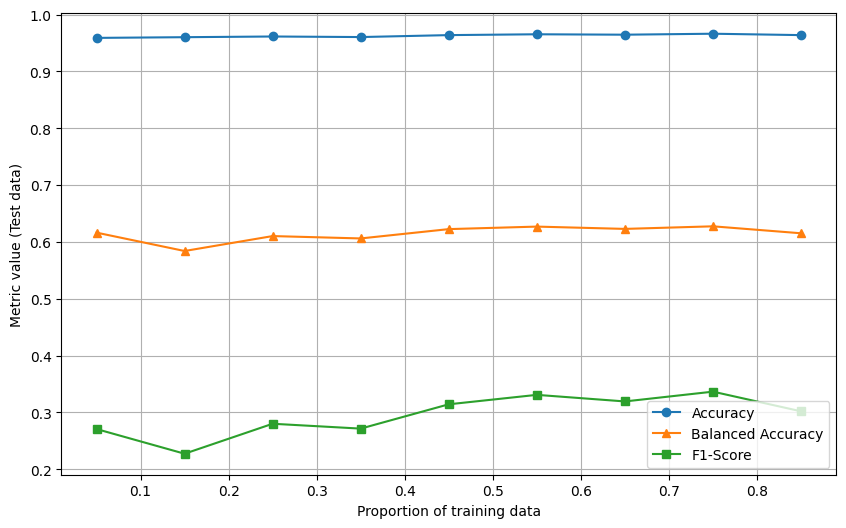

In [74]:
plot_acc_f1_across_subsets(X, y, n_seeds=2)

No difference

In [ ]:
parkinson = pd.read_csv('../data/raw/parkinson.csv')
X = parkinson.iloc[:, 1:-1].to_numpy()
y = parkinson.iloc[:, -1].to_numpy()

pd.concat([pd.DataFrame(X), pd.DataFrame(y)], axis=1).to_csv('../data/processed/parkinson.csv', index=False)

k = 5

plot_acc_f1_across_subsets(X, y, n_seeds=k, title=f'Parkinson ({k} seeds)')


Not great not terrible

Size: 0.05 | Acc: 0.5833 Bacc: 0.5493 F1: 0.4030 
Size: 0.15 | Acc: 0.5897 Bacc: 0.4936 F1: 0.2369 
Size: 0.25 | Acc: 0.5769 Bacc: 0.5244 F1: 0.3653 
Size: 0.35 | Acc: 0.6346 Bacc: 0.5521 F1: 0.3582 
Size: 0.45 | Acc: 0.5641 Bacc: 0.4745 F1: 0.2473 
Size: 0.55 | Acc: 0.5449 Bacc: 0.4854 F1: 0.3151 
Size: 0.65 | Acc: 0.5192 Bacc: 0.4412 F1: 0.2274 
Size: 0.75 | Acc: 0.4872 Bacc: 0.4022 F1: 0.1616 
Size: 0.85 | Acc: 0.5000 Bacc: 0.4168 F1: 0.1856 


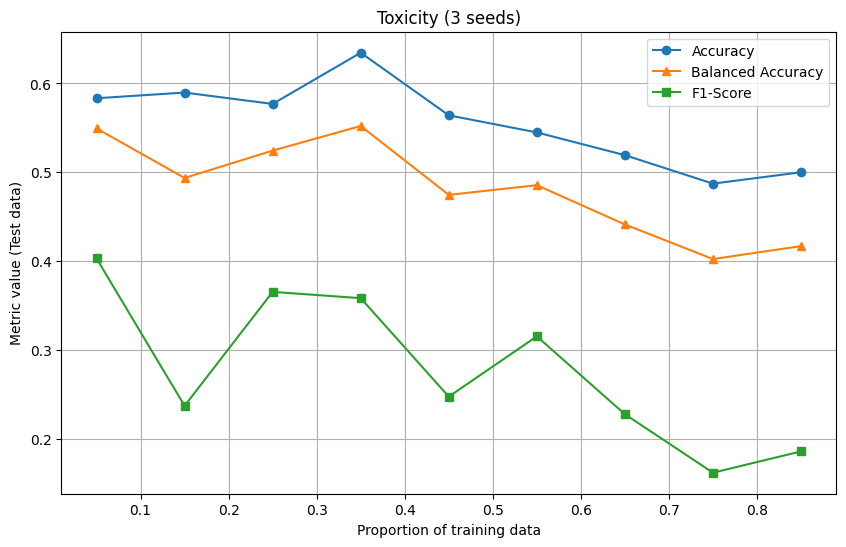

In [76]:
toxicity = pd.read_csv('../data/raw/toxicity.csv')
X = toxicity.iloc[:, :-1].to_numpy()
y = toxicity.iloc[:, -1].to_numpy()
y = np.where(y =='Toxic', 1, 0)

k = 3
plot_acc_f1_across_subsets(X, y, k, f'Toxicity ({k} seeds)')

wtf xd

### LSVT

In [ ]:
import arff

with open('../data/raw/lsvt.arff', 'r') as f:
    dataset = arff.load(f)

lsvt = pd.DataFrame(dataset['data'], columns=[attr[0] for attr in dataset['attributes']])
X = lsvt.iloc[:, :-1].to_numpy()
y = lsvt.iloc[:, [-1]].to_numpy().ravel()
y
y = np.where(y == '2', 1, 0).astype(int)

pd.concat([pd.DataFrame(X), pd.DataFrame(y)], axis=1).to_csv('../data/processed/lsvt.csv', index=False)

Size: 0.05 | Acc: 0.6053 Bacc: 0.4969 F1: 0.7365 
Size: 0.15 | Acc: 0.6447 Bacc: 0.5731 F1: 0.7423 
Size: 0.25 | Acc: 0.6974 Bacc: 0.6685 F1: 0.7600 
Size: 0.35 | Acc: 0.7500 Bacc: 0.6900 F1: 0.8225 
Size: 0.45 | Acc: 0.8026 Bacc: 0.7300 F1: 0.8649 
Size: 0.55 | Acc: 0.8289 Bacc: 0.7777 F1: 0.8788 
Size: 0.65 | Acc: 0.8289 Bacc: 0.7777 F1: 0.8787 
Size: 0.75 | Acc: 0.8158 Bacc: 0.7585 F1: 0.8710 
Size: 0.85 | Acc: 0.8158 Bacc: 0.7677 F1: 0.8682 
Size: 0.95 | Acc: 0.8289 Bacc: 0.7869 F1: 0.8763 


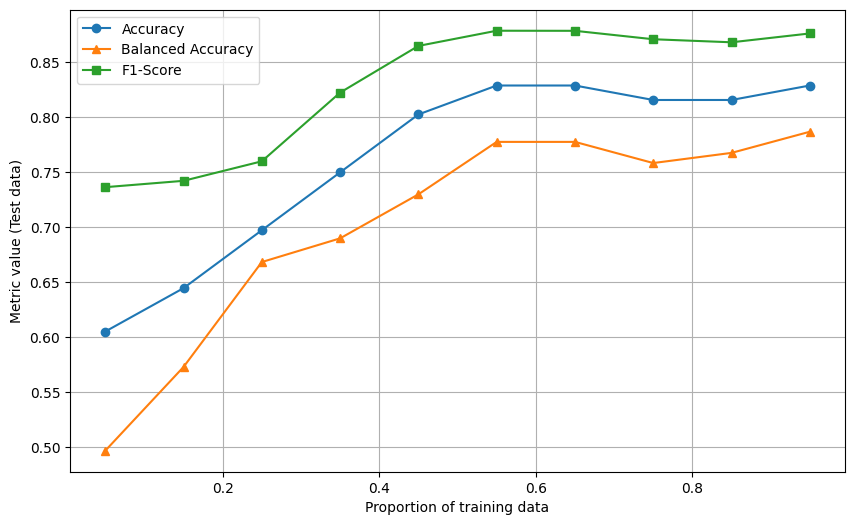

In [166]:
plot_acc_f1_across_subsets(X, y, n_seeds=2)

Good

Size: 0.05 | Acc: 0.5833 Bacc: 0.5805 F1: 0.6114 
Size: 0.15 | Acc: 0.6992 Bacc: 0.6991 F1: 0.7118 
Size: 0.25 | Acc: 0.7214 Bacc: 0.7199 F1: 0.7402 
Size: 0.35 | Acc: 0.7452 Bacc: 0.7448 F1: 0.7603 
Size: 0.45 | Acc: 0.7421 Bacc: 0.7428 F1: 0.7539 
Size: 0.55 | Acc: 0.7421 Bacc: 0.7432 F1: 0.7518 
Size: 0.65 | Acc: 0.7722 Bacc: 0.7736 F1: 0.7810 
Size: 0.75 | Acc: 0.7825 Bacc: 0.7861 F1: 0.7848 
Size: 0.85 | Acc: 0.7762 Bacc: 0.7796 F1: 0.7796 
Size: 0.95 | Acc: 0.7825 Bacc: 0.7860 F1: 0.7857 


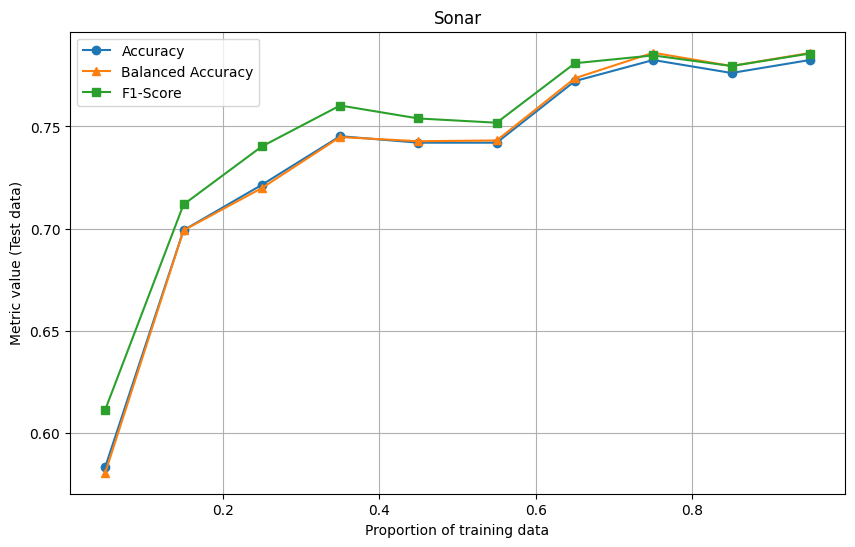

In [14]:
sonar = pd.read_csv('../data/raw/sonar.all-data', header=None)
X = sonar.iloc[:, :-1].to_numpy()
y = sonar.iloc[:, [-1]].to_numpy().ravel()
y = np.where(y == 'R', 0, 1)

plot_acc_f1_across_subsets(X, y, n_seeds=20, title='Sonar')

## Check model performance

In [104]:
prostate = pd.read_csv('../data/processed/prostate.csv')
darwin = pd.read_csv('../data/processed/darwin.csv')
lsvt = pd.read_csv('../data/processed/lsvt.csv')
parkinson = pd.read_csv('../data/processed/parkinson.csv')

datasets = {
    'prostate': prostate,
    'darwin': darwin,
    'lsvt': lsvt,
    'parkinson': parkinson
}

# X = prostate.iloc[:, :-1].to_numpy()
# y = prostate.iloc[:, [-1]].to_numpy().ravel()


Dataset: prostate
Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4
Dataset: darwin
Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4
Dataset: lsvt
Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4
Dataset: parkinson
Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4


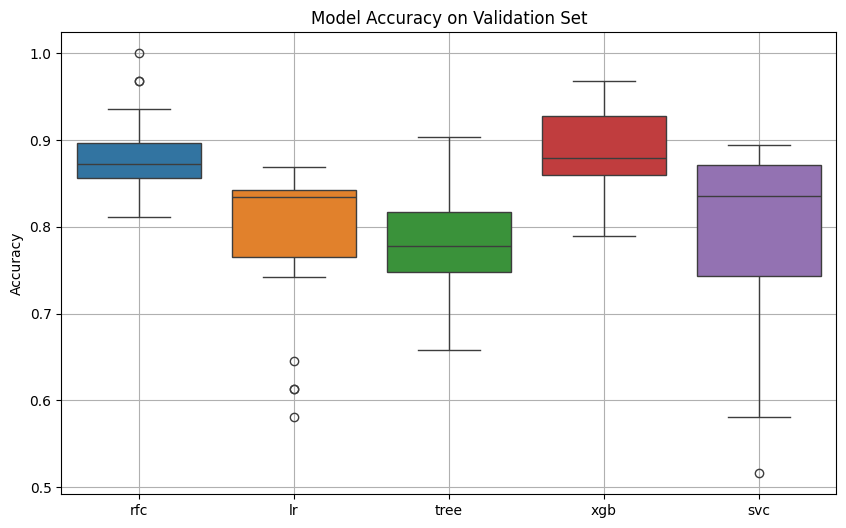

In [113]:
import time
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from time import perf_counter
import seaborn as sns

n = 5
results = {
    "rfc": [],
    "lr": [],
    "tree": [],
    "xgb": [],
    "svc": [],
}
time_results = {
    "rfc": [],
    "lr": [],
    "tree": [],
    "xgb": [],
    "svc": [],
}

scaler = StandardScaler()

for name, dataset in datasets.items():
    print(f"Dataset: {name}")
    X = dataset.iloc[:, :-1].to_numpy()
    y = dataset.iloc[:, -1].to_numpy()

    for i in range(n):
        print(f"Seed: {i}")
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y, random_state=i)
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_val = scaler.transform(X_val)

        start_time = perf_counter()
        rfc = RandomForestClassifier().fit(X_train, y_train)
        results["rfc"].append(accuracy_score(y_val, rfc.predict(X_val)))
        time_results["rfc"].append(perf_counter() - start_time)

        start_time = perf_counter()
        lr = LogisticRegression(solver='lbfgs', l1_ratio=0, C=1, max_iter=1000).fit(X_train, y_train)
        results["lr"].append(accuracy_score(y_val, lr.predict(X_val)))
        time_results["lr"].append(perf_counter() - start_time)

        start_time = perf_counter()
        tree = DecisionTreeClassifier().fit(X_train, y_train)
        results["tree"].append(accuracy_score(y_val, tree.predict(X_val)))
        time_results["tree"].append(perf_counter() - start_time)
    
        start_time = perf_counter()
        xgb = XGBClassifier().fit(X_train, y_train)
        results["xgb"].append(accuracy_score(y_val, xgb.predict(X_val)))
        time_results["xgb"].append(perf_counter() - start_time)

        start_time = perf_counter()
        svc = SVC(C=10).fit(X_train, y_train)
        results["svc"].append(accuracy_score(y_val, svc.predict(X_val)))
        time_results["svc"].append(perf_counter() - start_time)

results = pd.DataFrame(results)
time_results = pd.DataFrame(time_results)

plt.figure(figsize=(10, 6))
sns.boxplot(results)
plt.title("Model Accuracy on Validation Set")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

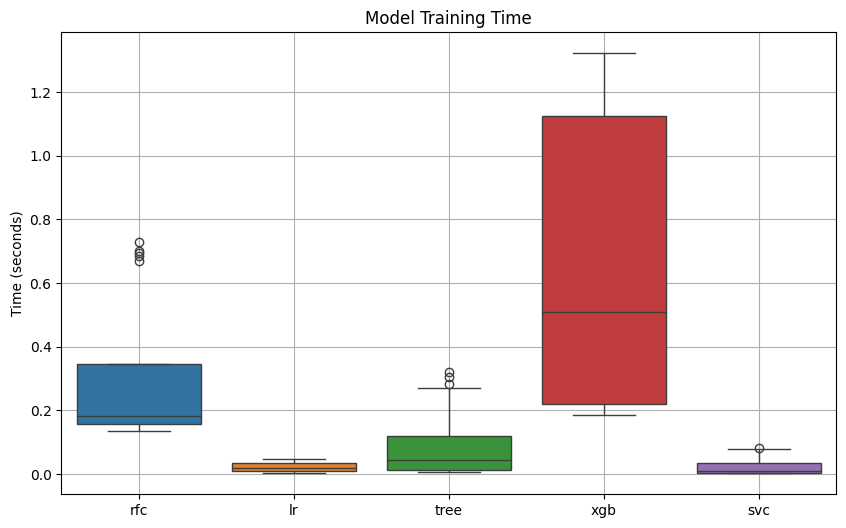

In [114]:
plt.figure(figsize=(10, 6))
sns.boxplot(time_results)
plt.title("Model Training Time")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()